# Regulator 위치 찾기

In [1]:
import pandas as pd

# 파일의 처음 5줄만 읽어서 구조 확인하기
bed_file = 'GRCh38-cCREs.bed'

try:
    # 구분자를 탭(\t)으로 지정하고, 헤더 없이 읽기
    df_head = pd.read_csv(bed_file, sep='\t', header=None, nrows=5)
    print("--- 파일의 첫 5줄 ---")
    print(df_head)
except Exception as e:
    print(f"읽기 실패: {e}")

--- 파일의 첫 5줄 ---
      0      1      2             3  4  5      6      7           8
0  chr1  10033  10250  EH38E2776516  0  .  10033  10250   255,167,0
1  chr1  10385  10713  EH38E2776517  0  .  10385  10713   255,167,0
2  chr1  16097  16381  EH38E3951272  0  .  16097  16381   0,176,240
3  chr1  17343  17642  EH38E3951273  0  .  17343  17642  190,40,229
4  chr1  29320  29517  EH38E3951274  0  .  29320  29517   6,218,147


In [2]:
import pandas as pd
import mygene
import os

def get_enhancers_by_color(gene_name, bed_file_path, dist_kb=100):
    # 1. 파일 확인
    if not os.path.exists(bed_file_path):
        return print(f"❌ 파일을 찾을 수 없습니다: {bed_file_path}")

    # 2. 유전자 좌표 찾기 (MyGene)
    mg = mygene.MyGeneInfo()
    gene_info = mg.query(gene_name, scopes='symbol', fields='genomic_pos,symbol', species='human')
    
    if not gene_info or 'hits' not in gene_info or not gene_info['hits']:
        return print(f"❌ '{gene_name}' 유전자를 찾을 수 없습니다.")

    g_pos = gene_info['hits'][0].get('genomic_pos')
    if isinstance(g_pos, list): g_pos = g_pos[0] # 여러 개면 첫 번째 선택
        
    chrom = f"chr{g_pos['chr']}"
    # TSS 결정 (Strand 고려)
    tss = g_pos['start'] if g_pos['strand'] == 1 else g_pos['end']
    
    print(f"🧬 Gene: {gene_name} ({chrom}:{tss}) | Searching ±{dist_kb}kb...")

    # 3. BED 파일 로드 (RGB 컬럼 활용)
    # 컬럼: chrom(0), start(1), end(2), accession(3), ..., rgb(8)
    try:
        # 9개 컬럼을 읽음
        df = pd.read_csv(bed_file_path, sep='\t', header=None, 
                         usecols=[0, 1, 2, 3, 8], # 필요한 컬럼만
                         names=['chrom', 'start', 'end', 'accession', 'itemRgb'])
    except Exception as e:
        return print(f"❌ 파일 읽기 실패: {e}")

    # 4. 위치 필터링
    search_start = tss - (dist_kb * 1000)
    search_end = tss + (dist_kb * 1000)
    
    df_filtered = df[
        (df['chrom'] == chrom) & 
        (df['end'] >= search_start) & 
        (df['start'] <= search_end)
    ].copy()

    # 5. 색상 코드로 분류 (RGB Mapping)
    # 공백이 있을 수 있으므로 문자열 처리
    df_filtered['itemRgb'] = df_filtered['itemRgb'].astype(str).str.strip()

    p_els = df_filtered[df_filtered['itemRgb'] == '255,167,0'].copy() # 오렌지색
    d_els = df_filtered[df_filtered['itemRgb'] == '255,205,0'].copy() # 노란색
    promoters = df_filtered[df_filtered['itemRgb'] == '255,0,0'].copy() # 빨간색

    # 거리 계산
    for data in [p_els, d_els, promoters]:
        if not data.empty:
            data['dist_from_tss'] = ((data['start'] + data['end']) / 2 - tss).astype(int)

    return {'pELS': p_els, 'dELS': d_els, 'PLS': promoters}

# --- 실행 ---
bed_file = 'GRCh38-cCREs.bed' # 파일명 확인!
result = get_enhancers_by_color('HBB', bed_file, dist_kb=50)

if result:
    print(f"\n📊 검색 결과:")
    print(f"- Proximal Enhancers (pELS): {len(result['pELS'])}개")
    print(f"- Distal Enhancers (dELS): {len(result['dELS'])}개")
    print(f"- Promoters (PLS): {len(result['PLS'])}개")
    
    if not result['pELS'].empty:
        print("\n🔎 [pELS] 예시:")
        print(result['pELS'][['chrom', 'start', 'end', 'dist_from_tss']].head())
    
    if not result['dELS'].empty:
        print("\n🔎 [dELS] 예시:")
        print(result['dELS'][['chrom', 'start', 'end', 'dist_from_tss']].head())

Input sequence provided is already in string format. No operation performed


🧬 Gene: HBB (chr11:5229395) | Searching ±50kb...

📊 검색 결과:
- Proximal Enhancers (pELS): 38개
- Distal Enhancers (dELS): 34개
- Promoters (PLS): 6개

🔎 [pELS] 예시:
         chrom    start      end  dist_from_tss
1491516  chr11  5205904  5206175         -23355
1491529  chr11  5224200  5224360          -5115
1491531  chr11  5225149  5225366          -4137
1491532  chr11  5225508  5225850          -3716
1491536  chr11  5228142  5228328          -1160

🔎 [dELS] 예시:
         chrom    start      end  dist_from_tss
1491506  chr11  5196139  5196428         -33111
1491507  chr11  5196822  5197151         -32408
1491520  chr11  5209470  5209685         -19817
1491521  chr11  5210486  5210830         -18737
1491539  chr11  5229412  5229756            189


# Regulator 확인

## HBB_LCR N-치환 영향 분석 (AlphaGenome)

- A. AlphaGenome 로드
- B. HBB/LCR 좌표 확인
- C. N-치환 variant 생성
- D. predict_variant 실행
- E. HBB RNA-seq 지표 계산
- F. 시각화/결과 요약


In [3]:
# A. AlphaGenome 로드
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome.data import genome, gene_annotation
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components as pc

sys.path.append(str(Path('..').resolve()))
from utils import (
    get_dna_model,
    load_gtf_feather,
    get_sequence_from_ensembl_region,
    normalize_sequence,
    prepare_gtf_views,
    build_transcript_extractors,
)

dna_model = get_dna_model()
gtf = load_gtf_feather()
output_metadata = dna_model.output_metadata(organism=dna_client.Organism.HOMO_SAPIENS)

gtf_transcript, gtf_longest_transcript = prepare_gtf_views(gtf)
_, longest_transcript_extractor = build_transcript_extractors(gtf_transcript, gtf_longest_transcript)
print('Loaded AlphaGenome client + GTF successfully')


gencode.v46.annotation.gtf.gz.feather already exists!
Loaded AlphaGenome client + GTF successfully


In [13]:
# B. HBB/LCR 좌표 확인 + 입력 interval 결정
GENE = 'HBE1'
LCR_CHROM = 'chr11'
LCR_START = 5_280_000
LCR_END = 5_295_000
SEQ_LEN = 2**20  # 1Mb

chrom_col = 'Chromosome' if 'Chromosome' in gtf.columns else 'chromosome'
start_col = 'Start' if 'Start' in gtf.columns else 'start'
end_col = 'End' if 'End' in gtf.columns else 'end'
strand_col = 'Strand' if 'Strand' in gtf.columns else 'strand'

hbb_gene_row = gtf[(gtf['gene_name'] == GENE) & (gtf['Feature'] == 'gene')].iloc[0]
hbb_chrom = str(hbb_gene_row[chrom_col])
hbb_start = int(hbb_gene_row[start_col])
hbb_end = int(hbb_gene_row[end_col])
hbb_strand = str(hbb_gene_row[strand_col])

gene_interval = gene_annotation.get_gene_interval(gtf, gene_symbol=GENE)
interval = gene_interval.resize(SEQ_LEN)

def _norm_chrom(c: str) -> str:
    c = str(c)
    return c if c.startswith('chr') else f'chr{c}'

def _style_chrom(template: str, chrom: str) -> str:
    if str(template).startswith('chr'):
        return _norm_chrom(chrom)
    return str(chrom).replace('chr', '')

interval_chrom = interval.chromosome
lcr_chrom_for_model = _style_chrom(interval_chrom, LCR_CHROM)

def interval_contains(iv, chrom, start, end):
    iv_chrom = _norm_chrom(iv.chromosome)
    target_chrom = _norm_chrom(chrom)
    return (iv_chrom == target_chrom) and (iv.start <= start) and (iv.end >= end)

contains_hbb = interval_contains(interval, hbb_chrom, hbb_start, hbb_end)
contains_lcr = interval_contains(interval, lcr_chrom_for_model, LCR_START, LCR_END)

if not (contains_hbb and contains_lcr):
    merged_start = min(hbb_start, LCR_START)
    merged_end = max(hbb_end, LCR_END)
    center = (merged_start + merged_end) // 2
    half = SEQ_LEN // 2
    interval = genome.Interval(
        interval_chrom,
        max(1, center - half),
        center + half,
        strand=hbb_strand,
        name=f'{GENE}_with_LCR'
    )

contains_hbb = interval_contains(interval, hbb_chrom, hbb_start, hbb_end)
contains_lcr = interval_contains(interval, lcr_chrom_for_model, LCR_START, LCR_END)

assert contains_hbb, 'Interval does not include HBB gene body.'
assert contains_lcr, 'Interval does not include HBB_LCR region.'

vis_start = max(1, min(hbb_start, LCR_START) - 5_000)
vis_end = max(hbb_end, LCR_END) + 5_000
interval_vis = genome.Interval(interval_chrom, vis_start, vis_end, strand=hbb_strand)

print(f'HBB gene: {_norm_chrom(hbb_chrom)}:{hbb_start}-{hbb_end} (strand={hbb_strand})')
print(f'LCR region: {_norm_chrom(lcr_chrom_for_model)}:{LCR_START}-{LCR_END}')
print(f'Analysis interval: {_norm_chrom(interval.chromosome)}:{interval.start}-{interval.end} (width={interval.width:,})')


HBB gene: chr11:5268344-5505652 (strand=-)
LCR region: chr11:5280000-5295000
Analysis interval: chr11:4862710-5911286 (width=1,048,576)


In [14]:
# C. N-치환 variant 생성
ref_seq = normalize_sequence(
    get_sequence_from_ensembl_region(
        species='human',
        chrom=lcr_chrom_for_model,
        start=LCR_START,
        end=LCR_END,
        strand=1,
        coord_system_version='GRCh38',
    )
)
alt_seq = 'N' * len(ref_seq)

assert len(ref_seq) == 15_000, f'Expected 15000bp, got {len(ref_seq)}'
assert len(alt_seq) == len(ref_seq), 'REF/ALT length mismatch'
assert set(alt_seq) == {'N'}, 'ALT must be all N'

variant = genome.Variant(
    chromosome=lcr_chrom_for_model,
    position=LCR_START,
    reference_bases=ref_seq,
    alternate_bases=alt_seq,
    name='HBB_LCR_all_N',
)

print('Variant checks passed')
print('REF length:', len(ref_seq), '| ALT length:', len(alt_seq), '| ALT alphabet:', sorted(set(alt_seq)))


Variant checks passed
REF length: 15000 | ALT length: 15000 | ALT alphabet: ['N']


In [15]:
# D. predict_variant 실행
requested_outputs = {dna_client.OutputType.RNA_SEQ}

output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=requested_outputs,
    ontology_terms=['CL:0002328'],
)

ref_rna = output.reference.rna_seq.filter_to_negative_strand()
alt_rna = output.alternate.rna_seq.filter_to_negative_strand()

print('predict_variant completed')
print('REF RNA shape:', ref_rna.values.shape, '| ALT RNA shape:', alt_rna.values.shape)


predict_variant completed
REF RNA shape: (1048576, 1) | ALT RNA shape: (1048576, 1)


In [16]:
# E. HBB RNA-seq 지표 계산
ALLOWED_ASSAYS = ['total RNA-seq', 'polyA plus RNA-seq']
EPS = 1e-6

def filter_assays(track_data, allowed_assays):
    meta = track_data.metadata
    mask = meta['Assay title'].isin(allowed_assays).to_numpy()
    if mask.sum() == 0:
        raise ValueError('No RNA-seq tracks left after assay filtering.')
    return track_data.filter_tracks(mask), mask

def gene_body_bin_mask(track_interval, gene_start, gene_end, n_bins):
    edges = np.linspace(track_interval.start, track_interval.end, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    return (centers >= gene_start) & (centers <= gene_end), centers

ref_rna_filt, assay_mask = filter_assays(ref_rna, ALLOWED_ASSAYS)
alt_rna_filt = alt_rna.filter_tracks(assay_mask)

track_interval = getattr(ref_rna_filt, 'interval', interval)
n_bins = ref_rna_filt.values.shape[0]
hbb_mask, bin_centers = gene_body_bin_mask(track_interval, hbb_start, hbb_end, n_bins)

if hbb_mask.sum() == 0:
    raise ValueError('HBB gene-body does not overlap any RNA bins. Increase interval/inspect coordinates.')

ref_vals = ref_rna_filt.values[hbb_mask, :]
alt_vals = alt_rna_filt.values[hbb_mask, :]

hbb_gene_body_mean_ref = float(np.nanmean(ref_vals))
hbb_gene_body_mean_alt = float(np.nanmean(alt_vals))
hbb_gene_body_mean_delta = float(hbb_gene_body_mean_alt - hbb_gene_body_mean_ref)
hbb_gene_body_mean_log2fc = float(np.log2((hbb_gene_body_mean_alt + EPS) / (hbb_gene_body_mean_ref + EPS)))

summary_df = pd.DataFrame([
    {
        'gene': GENE,
        'gene_chrom': _norm_chrom(hbb_chrom),
        'gene_start': hbb_start,
        'gene_end': hbb_end,
        'gene_strand': hbb_strand,
        'lcr_chrom': _norm_chrom(lcr_chrom_for_model),
        'lcr_start': LCR_START,
        'lcr_end': LCR_END,
        'variant_length_bp': len(ref_seq),
        'n_rna_tracks_after_filter': int(ref_rna_filt.values.shape[1]),
        'hbb_gene_body_mean_ref': hbb_gene_body_mean_ref,
        'hbb_gene_body_mean_alt': hbb_gene_body_mean_alt,
        'hbb_gene_body_mean_delta': hbb_gene_body_mean_delta,
        'hbb_gene_body_mean_log2fc': hbb_gene_body_mean_log2fc,
    }
])

display(summary_df)


,gene,gene_chrom,gene_start,gene_end,gene_strand,lcr_chrom,lcr_start,lcr_end,variant_length_bp,n_rna_tracks_after_filter,hbb_gene_body_mean_ref,hbb_gene_body_mean_alt,hbb_gene_body_mean_delta,hbb_gene_body_mean_log2fc
0,HBE1,chr11,5268344,5505652,-,chr11,5280000,5295000,15000,1,0.000419,0.000388,-0.000031,-0.109712


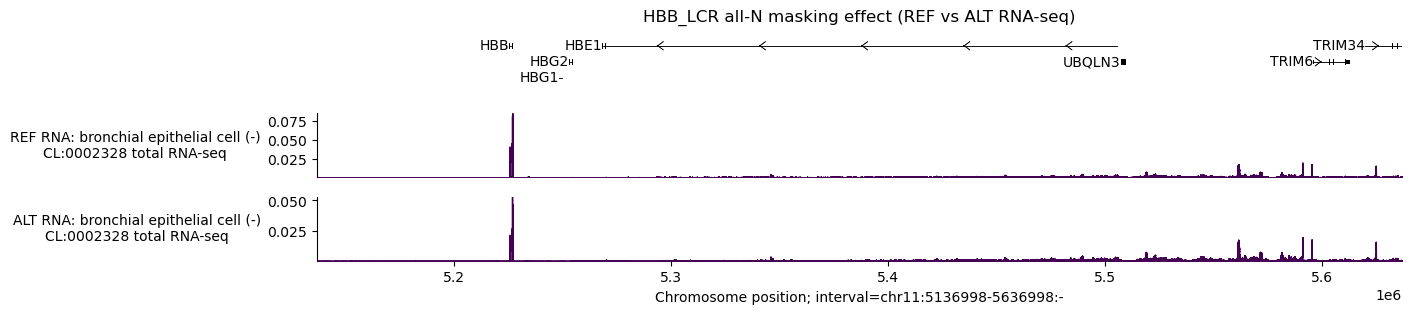

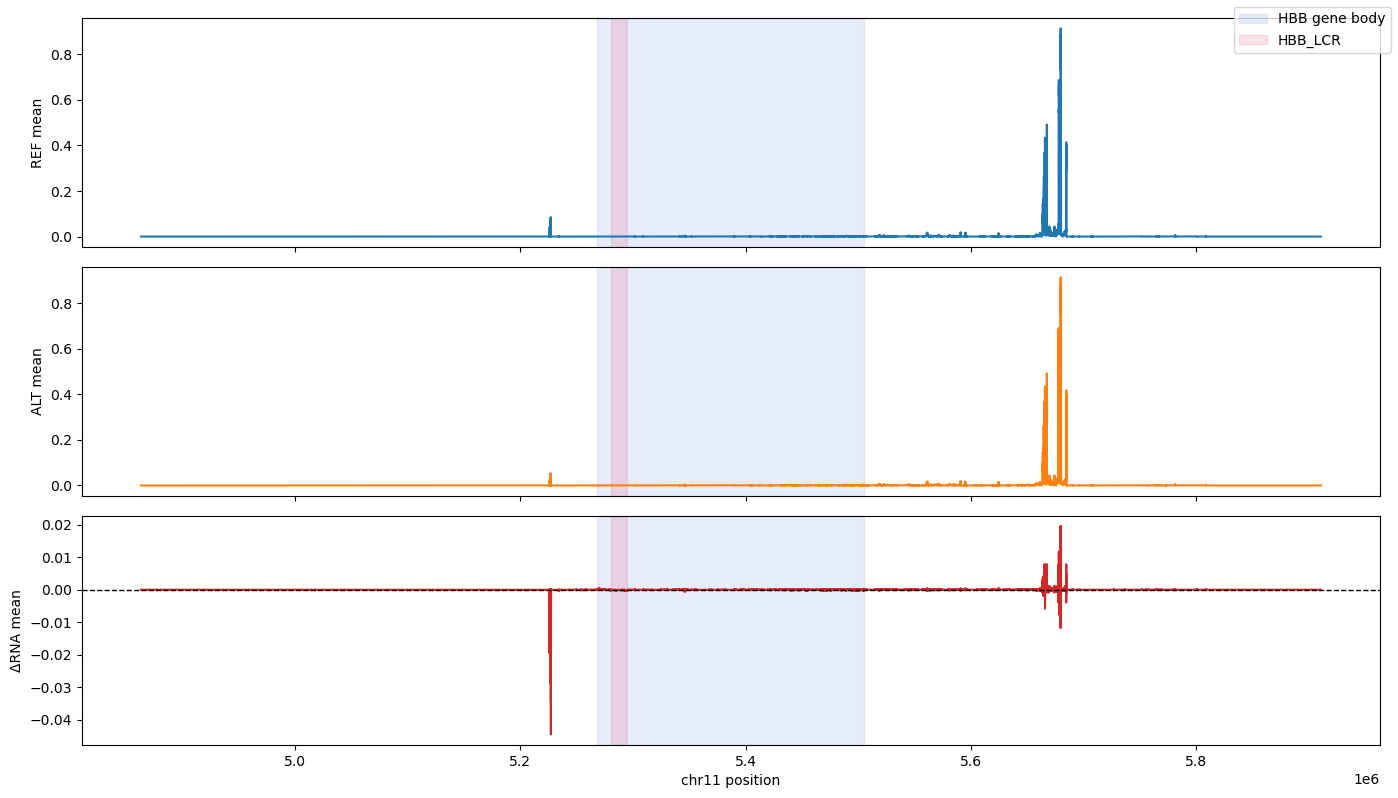

--- 핵심 요약 ---
gene gene_chrom  gene_start  gene_end gene_strand lcr_chrom  lcr_start  lcr_end  variant_length_bp  n_rna_tracks_after_filter  hbb_gene_body_mean_ref  hbb_gene_body_mean_alt  hbb_gene_body_mean_delta  hbb_gene_body_mean_log2fc
HBE1      chr11     5268344   5505652           -     chr11    5280000  5295000              15000                          1                0.000419                0.000388                 -0.000031                  -0.109712


In [30]:
# F. 시각화 + 결과 요약
longest_transcripts = longest_transcript_extractor.extract(interval)

annotations = [
    pc.IntervalAnnotation([genome.Interval(interval_chrom, LCR_START, LCR_END, name='HBB_LCR (N-mask)')], colors='crimson', alpha=0.2),
    pc.IntervalAnnotation([genome.Interval(interval_chrom, hbb_start, hbb_end, name='HBB gene body')], colors='royalblue', alpha=0.2),
]

components = [
    pc.TranscriptAnnotation(longest_transcripts),
    pc.Tracks(ref_rna_filt, filled=True, ylabel_template='REF RNA: {biosample_name} ({strand})\n{name}'),
    pc.Tracks(alt_rna_filt, filled=True, ylabel_template='ALT RNA: {biosample_name} ({strand})\n{name}'),
]

_ = pc.plot(
    components,
    # interval=interval_vis,
    interval=interval.resize(500000),
    # annotations=annotations,
    title='HBB_LCR all-N masking effect (REF vs ALT RNA-seq)',
    fig_width=14,
)

# ΔRNA(ALT-REF) 평균 트랙(필터된 트랙 평균) 시각화
ref_mean = np.nanmean(ref_rna_filt.values, axis=1)
alt_mean = np.nanmean(alt_rna_filt.values, axis=1)
delta_mean = alt_mean - ref_mean

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(bin_centers, ref_mean, color='tab:blue')
axes[0].set_ylabel('REF mean')
axes[1].plot(bin_centers, alt_mean, color='tab:orange')
axes[1].set_ylabel('ALT mean')
axes[2].plot(bin_centers, delta_mean, color='tab:red')
axes[2].axhline(0.0, color='black', linewidth=1, linestyle='--')
axes[2].set_ylabel('ΔRNA mean')
axes[2].set_xlabel(f'{_norm_chrom(interval_chrom)} position')

for ax in axes:
    ax.axvspan(hbb_start, hbb_end, color='royalblue', alpha=0.12, label='HBB gene body')
    ax.axvspan(LCR_START, LCR_END, color='crimson', alpha=0.12, label='HBB_LCR')

handles, labels = axes[0].get_legend_handles_labels()
if labels:
    fig.legend(handles[:2], labels[:2], loc='upper right')
plt.tight_layout()
plt.show()

print('--- 핵심 요약 ---')
print(summary_df.to_string(index=False))


In [1]:
# (Optional) 음성 대조: REF == ALT variant이면 Δ가 거의 0인지 확인
control_variant = genome.Variant(
    chromosome=lcr_chrom_for_model,
    position=LCR_START,
    reference_bases=ref_seq,
    alternate_bases=ref_seq,
    name='control_ref_eq_alt',
)
control_output = dna_model.predict_variant(
    interval=interval,
    variant=control_variant,
    requested_outputs={dna_client.OutputType.RNA_SEQ},
    ontology_terms=['CL:0002328'],
)
print('Control run completed')


NameError: name 'genome' is not defined

### Random ALT variant (REF vs ALT plot only)

아래 2개 셀은 기존 AlphaGenome 로드/좌표 셀(A~C) 실행 후 사용하세요.


In [27]:
# Random ALT sequence 생성 + predict_variant 실행
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ref_seq가 없으면 C 셀을 먼저 실행
if 'ref_seq' not in globals():
    raise RuntimeError('ref_seq가 없습니다. 먼저 C. N-치환 variant 생성 셀을 실행하세요.')

alt_seq_random = ''.join(rng.choice(np.array(list('ACGT')), size=len(ref_seq)))
variant_random = genome.Variant(
    chromosome=lcr_chrom_for_model,
    position=LCR_START,
    reference_bases=ref_seq,
    alternate_bases=alt_seq_random,
    name='HBB_LCR_random_seq',
)

output_random = dna_model.predict_variant(
    interval=interval,
    variant=variant_random,
    requested_outputs={dna_client.OutputType.RNA_SEQ},
    ontology_terms=['CL:0002328'],
)

ref_rna_random = output_random.reference.rna_seq.filter_to_negative_strand()
alt_rna_random = output_random.alternate.rna_seq.filter_to_negative_strand()

allowed_assays_random = ['total RNA-seq', 'polyA plus RNA-seq']
mask_random = ref_rna_random.metadata['Assay title'].isin(allowed_assays_random).to_numpy()
if mask_random.sum() == 0:
    raise ValueError('Assay filter 후 남는 RNA-seq 트랙이 없습니다.')

ref_rna_random_filt = ref_rna_random.filter_tracks(mask_random)
alt_rna_random_filt = alt_rna_random.filter_tracks(mask_random)

print('Random ALT variant ready')
print('seed:', RANDOM_SEED, '| random ALT length:', len(alt_seq_random), '| tracks:', ref_rna_random_filt.values.shape[1])


Random ALT variant ready
seed: 42 | random ALT length: 15000 | tracks: 1


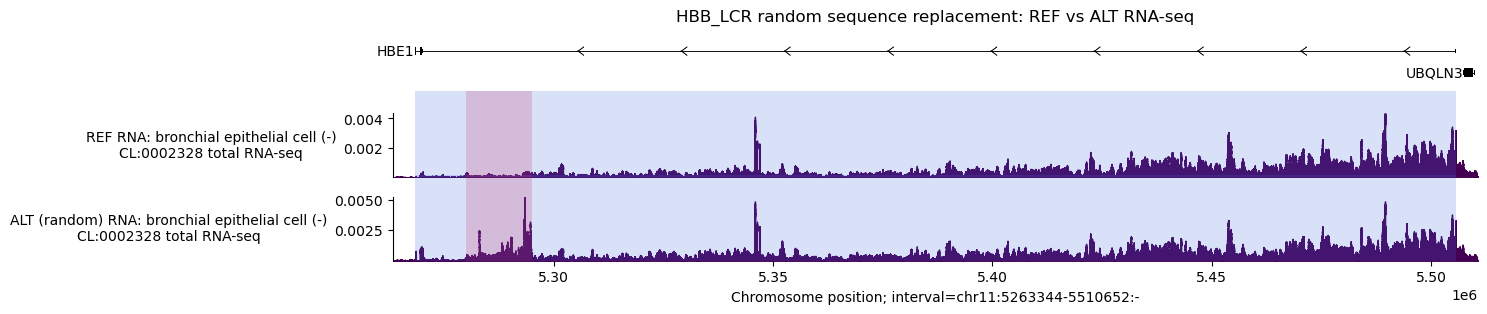

In [28]:
# REF vs ALT (random ALT) AlphaGenome plot
longest_transcripts_random = longest_transcript_extractor.extract(interval)

components_random = [
    pc.TranscriptAnnotation(longest_transcripts_random),
    pc.Tracks(
        ref_rna_random_filt,
        filled=True,
        ylabel_template='REF RNA: {biosample_name} ({strand})\n{name}'
    ),
    pc.Tracks(
        alt_rna_random_filt,
        filled=True,
        ylabel_template='ALT (random) RNA: {biosample_name} ({strand})\n{name}'
    ),
]

annotations_random = [
    pc.IntervalAnnotation(
        [genome.Interval(interval_chrom, LCR_START, LCR_END, name='HBB_LCR random-replaced')],
        colors='crimson',
        alpha=0.2,
    ),
    pc.IntervalAnnotation(
        [genome.Interval(interval_chrom, hbb_start, hbb_end, name='HBB gene body')],
        colors='royalblue',
        alpha=0.2,
    ),
]

_ = pc.plot(
    components_random,
    interval=interval_vis,
    annotations=annotations_random,
    title='HBB_LCR random sequence replacement: REF vs ALT RNA-seq',
    fig_width=14,
)
